# **Exploratory Data Analysis for Products and Sellers**
#### Finding Patterns in Products & Sellers **fix this when finished*

## Table of Contents

- [0. EDA for Products & Sellers Summary](#topic-0)
- [1. Import Libraries](#topic-1)
- [2. Import Data](#topic-2)
- [3. Analysis Section](#topic-3)
  - [3.1 ](#topic-3-1)
  - [3.2 ](#topic-3-2)
  - [3.3 ](#topic-3-3)
  - [3.4 ](#topic-3-4)
  - [3.5 ](#topic-3-5)
- [4. Conclusion & Insights Recap](#topic-4)
- [5. Recommendations based on Insights](#topic-5)


## **0. EDA for Products & Sellers Summary** <a id="topic-0"></a>

- texts

## **1. Import Libraries** <a id="topic-1"></a>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## **2. Import Data** <a id="topic-2"></a>

In [22]:
date_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_timestamp", "order_estimated_delivery_date"]

orders = pd.read_csv('../data/processed/orders.csv')
orders[date_cols] = orders[date_cols].apply(pd.to_datetime, errors='coerce')  # Safely parse all, fallback if weird values

orders["delivery_time_gap"] = pd.to_timedelta(orders["delivery_time_gap"], errors='coerce')

order_items = pd.read_csv('../data/processed/order_items.csv')
customers = pd.read_csv('../data/processed/customers.csv')
payments = pd.read_csv('../data/processed/payments.csv')
products = pd.read_csv('../data/processed/products.csv')

## **3. Analysis Section** <a id="topic-3"></a>
***alter with corresponding text when done***
- Data Exploration: This section dives deep into customer behavior, order performance, regional trends, and delivery dynamics statistical & visualization methods.
- Visual-Driven: Data is visualized through a variety of plots — bar plots, histograms, KDEs, line graphs — to surface hidden patterns and outliers.
- Contextual Commentary: Every insight is paired with interpretation to understand its potential business or logistic impact.
- Subsection-Focused: The section is divided into specific focus areas like Order Status, Delivery Timings, Monthly Trends, and Regional Insights.
- Real-World Takeaways: Each analysis aims to bring forward operational or strategic implications, making the data actionable.

In [23]:
#### Data Overview
products.head()

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,weight_volume_ratio
0,90K0C1fIyQUf,toys,491.0,19.0,12.0,16.0,3648.0,0.134594
1,qejhpMGGVcsl,watches_gifts,440.0,18.0,14.0,17.0,4284.0,0.102708
2,qUS5d2pEAyxJ,costruction_tools_garden,2200.0,16.0,16.0,16.0,4096.0,0.537109
3,639iGvMyv0De,toys,1450.0,68.0,3.0,48.0,9792.0,0.148080
4,1lycYGcsic2F,toys,300.0,17.0,4.0,12.0,816.0,0.367647


In [24]:
order_items.head()

,order_id,product_id,seller_id,price,shipping_charges,shipping_price_ratio
0,Axfy13Hk4PIk,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,0.378730
1,v6px92oS8cLG,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,0.139286
2,Ulpf9skrhjfm,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,0.269876
3,bwJVWupf2keN,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,0.116144
4,Dd0QnrMk9Cj5,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,0.039313


In [25]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_diff
0,Axfy13Hk4PIk,1,credit_card,1,259.14,49.02
1,v6px92oS8cLG,1,credit_card,8,382.39,-187.80
2,Ulpf9skrhjfm,1,credit_card,4,249.25,-167.47
3,bwJVWupf2keN,1,credit_card,2,27.79,267.43
4,Dd0QnrMk9Cj5,1,credit_card,1,76.15,734.41


In [26]:
customers.head()

,customer_id,customer_zip_code_prefix,customer_city,customer_state
0,hCT0x9JiGXBQ,58125,varzea paulista,SP
1,PxA7fv9spyhx,3112,armacao dos buzios,RJ
2,g3nXeJkGI0Qw,4119,jandira,SP
3,EOEsCQ6QlpIg,18212,uberlandia,MG
4,mVz5LO2Vd6cL,88868,ilhabela,SP


#### **3.1 Product Category Distribution** <a id="topic-3-1"></a>

***stuff about it***

In [27]:
len(products)

26344

In [28]:
product_categories_counts = products['product_category_name'].value_counts()
product_categories_counts

product_category_name
toys                                 19890
bed_bath_table                         629
sports_leisure                         610
furniture_decor                        534
health_beauty                          513
                                     ...  
flowers                                  2
home_comfort_2                           1
furniture_mattress_and_upholstery        1
fashion_childrens_clothes                1
security_and_services                    1
Name: count, Length: 69, dtype: int64

**This shows that:**
- Toys are most prominent category among all 26344 products, 19890 (about 75.5%) products are toys.
- And this is over 30 times the product category which is second to it.
- While some categories exist with only a few products (as few as 1).

In [29]:
len(product_categories_counts[product_categories_counts.values < 50])

44

**This shows that:**
- More than half (44, total categories = 69) of the product categories have less than 50 products.
- We will try to plot these separately, and higher ones separately. And probably try to not include the toys category as it diminishes the rest of the data.

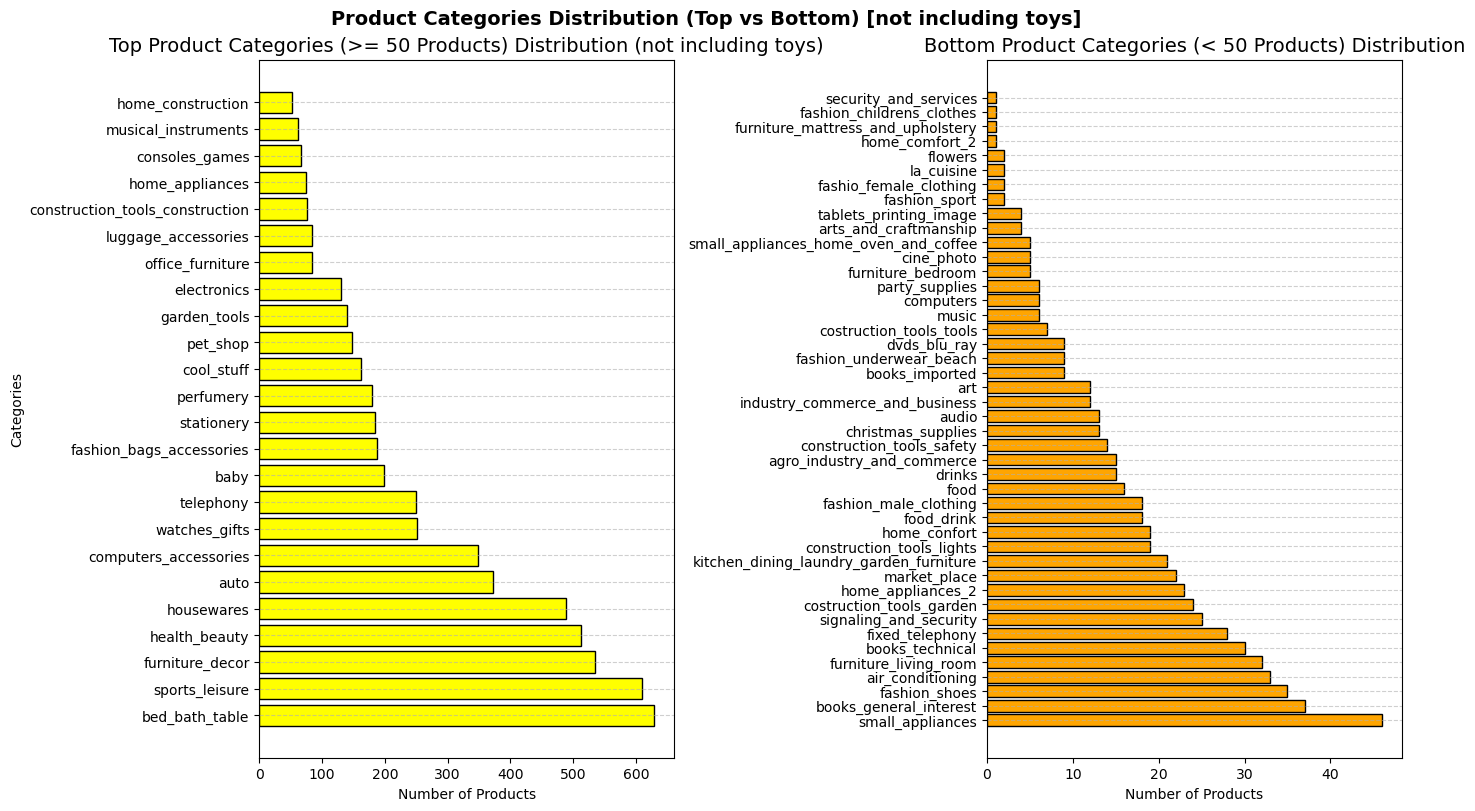

In [30]:
top_categories = product_categories_counts[product_categories_counts.between(50, 1000)] # not including toys
bottom_categories = product_categories_counts[product_categories_counts < 50] # categories with less than 50 products.
fig, axes = plt.subplots(1, 2, figsize=(14, 8), constrained_layout=True)

# Bar Plot for top categories
axes[0].barh(top_categories.index, top_categories.values, color='yellow', edgecolor='black')
axes[0].set_title("Top Product Categories (>= 50 Products) Distribution (not including toys)", fontsize=14)
axes[0].set_ylabel("Categories")
axes[0].set_xlabel("Number of Products")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# bar plot for bottom categories
axes[1].barh(bottom_categories.index, bottom_categories.values, color='orange', edgecolor='black')
axes[1].set_title("Bottom Product Categories (< 50 Products) Distribution", fontsize=14)
axes[1].set_xlabel("Number of Products")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle("Product Categories Distribution (Top vs Bottom) [not including toys]", fontsize=14, fontweight='bold')
plt.show()

**This implies that:**
- Maximum number of product categories have less than a 100 products.
- Many bottom categories with low number of products can be combined to create a single category such as fashion and furniture, as there are many sub-categories of these categories with small number of products.

---
#### **3.2 Topic** <a id="topic-3-2"></a>

In [31]:
products.describe()

,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,weight_volume_ratio
count,26344.000000,26344.000000,26344.000000,26344.000000,26344.000000,26344.000000
mean,2254.583055,30.670855,16.880390,23.110955,16361.967507,0.203561
std,4227.208850,16.767689,13.632374,11.973130,26678.952261,0.979014
min,2.000000,7.000000,2.000000,6.000000,168.000000,0.000220
25%,300.000000,18.000000,8.000000,15.000000,2860.000000,0.066667
50%,700.000000,25.000000,13.000000,20.000000,6732.000000,0.116550
75%,1850.000000,38.000000,20.000000,30.000000,18032.000000,0.195312
max,40425.000000,105.000000,105.000000,118.000000,294000.000000,65.909091


**This implies that:**
- Average weight and volume of a product is 2254 grams & 19362 cm^3 (approx.)
- And from the quartile values we can understand that 75% of the products weigh less than 1.85 kg & volume less than 18032 cm^3. This suggests that most of the products are lighter than 2 kgs while some products have very high weight that goes upto 40 kgs.
- Similarly for volume: Generally volume is less than 18032 cm^3 or 18 L. (approx.) while some go upto 294 L.

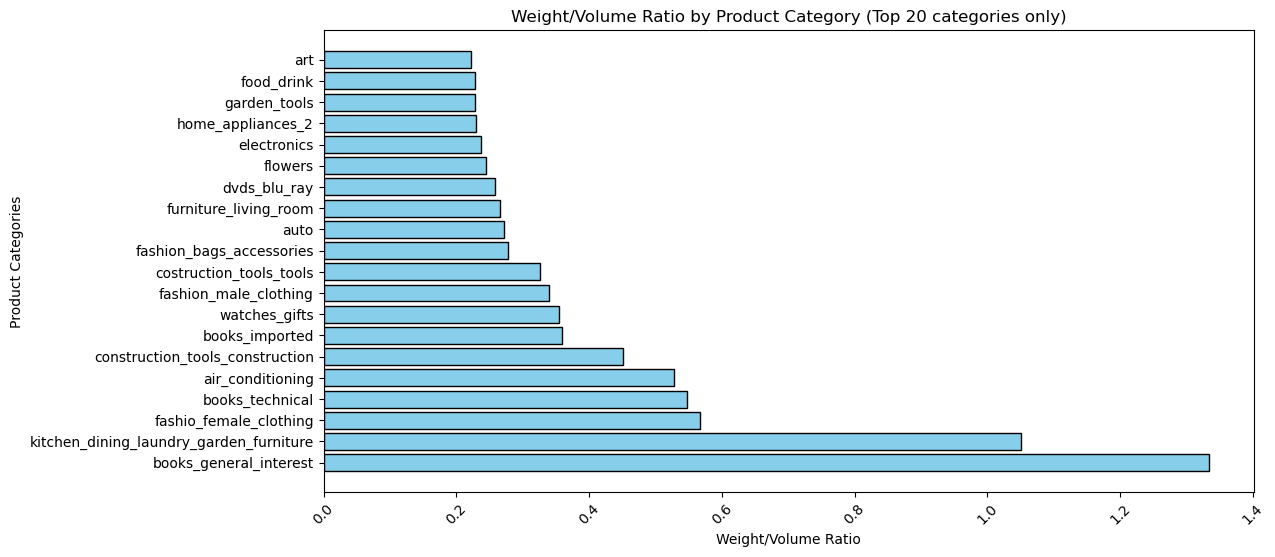

In [55]:
weight_volume_by_category = products.groupby('product_category_name')[['product_weight_g', 'product_volume_cm3', 'weight_volume_ratio']].mean().sort_values(by='weight_volume_ratio', ascending=False)
plt.figure(figsize=(12,6))
plt.barh(weight_volume_by_category.head(20).index, weight_volume_by_category['weight_volume_ratio'].head(20), color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Weight/Volume Ratio')
plt.ylabel('Product Categories')
plt.title('Weight/Volume Ratio by Product Category (Top 20 categories only)')
plt.show()

**This implies that:**
- Books, in general, have around 0.9 to 1.5 g/cm3 weight/volume ratio, this high value(approx 1.35) for this ratio signifies that most books must be hardcover or coffee table books as they have higher weight/volume ratio compared to paperback.
- The second highest weight/volume ratio is for furniture for kitchen/dining/garden, this is expected to have high weight volume ratio as they include smaller pieces of furniture (leading to low volume), resulting in high w/v ratio.
- Most of the product categories have weight/volume ratio < 0.2, which means that most categories weigh very less compared to their size. Thus, for these categories delivery services and logistics with more volume capacity is needed while weight taking capacity can be lower, as volume is a bigger factor here, compared to weight.

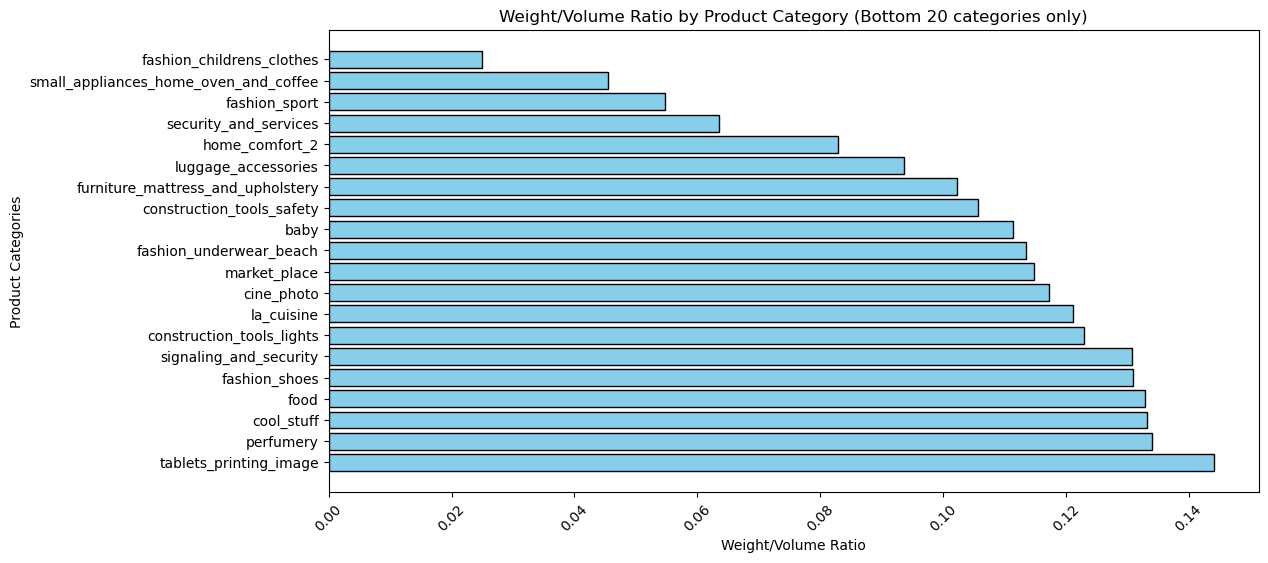

In [56]:
plt.figure(figsize=(12,6))
plt.barh(weight_volume_by_category.tail(20).index, weight_volume_by_category['weight_volume_ratio'].tail(20), color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Weight/Volume Ratio')
plt.ylabel('Product Categories')
plt.title('Weight/Volume Ratio by Product Category (Bottom 20 categories only)')
plt.show()

**This implies that:**
- Most of the categories in the bottom 20 categories are generally light, leading to low weight and less weight/volume ratio, hence these categories have low weight/volume ratio.
- This may also be due to large volume compared to size, like the category furniture_mattress_upholstery (includes mattresses & upholstery) which are generally large in volume but very light due to the material they are made of.

---
#### **3.3 Topic** <a id="topic-3-3"></a>

---
#### **3.4 Topic** <a id="topic-3-4"></a>

---
#### **3.5 Topic** <a id="topic-3-5"></a>

---
## **4. Conclusion & Insights Recap** <a id="topic-4"></a>

***subtext***

---
## **5. Recommendations based on Insights** <a id="topic-5"></a>
***subtext***